In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.special as sp
import sympy
from IPython.display import Image
from matplotlib import rc

import warnings

import utils

warnings.simplefilter("ignore")

In [2]:
workdir = 'figures/tertiary_current'
utils.make_dir_if_missing(workdir)

In [3]:
labelsize = 14
figsize = (5, 4.5)
ext = "eps"
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
params = {
    'figure.figsize': figsize,
    # 'text.usetex' : True,
    'font.size' : 12,
    # 'font.family' : 'iopams',
    'axes.labelsize': labelsize,
    'legend.fontsize': 12,
    # 'text.latex.unicode': True,
}
plt.rcParams.update(params)

In [4]:
def get_simulation_metafile_path(Wa_p, kr, gamma, resolution, kinetics="butler_volmer"):
    return os.path.join("output/tertiary_current/150-40-0", str(resolution), kinetics, f"0.001-{Wa_p}-{kr}", str(gamma), "simulation.json")

In [5]:
def read_simulation_metafile(metafile_path):
    with open(metafile_path, "r") as fp:
        return json.load(fp)

In [6]:
df_rows = []
wagner_nums = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
krs = [0.01, 1.0, 100.0]

for Wa_p in wagner_nums:
    for kr in krs:
        sim_metafile = get_simulation_metafile_path(resolution=0.005, kr=kr, Wa_p=Wa_p, gamma=15.0)
        try:
            row_data = read_simulation_metafile(sim_metafile)
        except FileNotFoundError:
            print(sim_metafile)
            continue
        df_rows.append(row_data)

df = pd.DataFrame(df_rows)

In [7]:
df.head()

,I left [A],I interface [A],I right [A],resistance [ohm.cm2],time elapsed [s],solve time [s],L ref [m],c ref [mol/m3],phi ref [V],t ref [s],Positive Wa,Kr,kinetics,dofs
0,-0.000388,-0.000374,0.000388,7223.939073,2.366023,1.608455,0.00015,35000,4.25,22500000.0,0.001,0.01,butler_volmer,112836
1,-0.000766,-0.000678,0.000766,3654.310922,3.860797,2.671916,0.00015,35000,4.25,22500000.0,0.001,1.00,butler_volmer,112836
2,-0.000802,-0.000683,0.000802,3490.902724,7.389474,2.586740,0.00015,35000,4.25,22500000.0,0.001,100.00,butler_volmer,112836
3,-0.000384,-0.000371,0.000384,7287.161807,7.481344,2.673103,0.00015,35000,4.25,22500000.0,0.010,0.01,butler_volmer,112836
4,-0.000766,-0.000678,0.000766,3654.792511,6.938306,2.423518,0.00015,35000,4.25,22500000.0,0.010,1.00,butler_volmer,112836


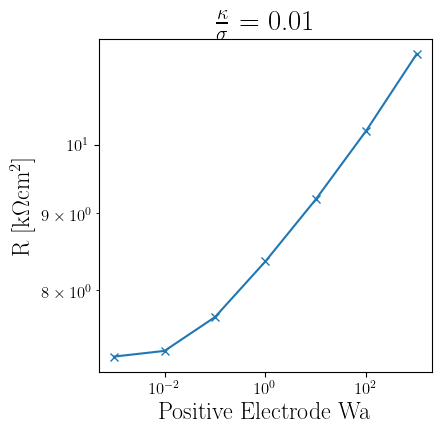

In [8]:
df_001 = df[np.isclose(df["Kr"], 0.01)]
slope_001 = []
x = df_001['Positive Wa'].to_numpy()
y = df_001['resistance [ohm.cm2]'].to_numpy()
for i in range(len(wagner_nums) - 1):
    slope_001.append((y[i+1] - y[i])/(x[i+1] - x[i]))
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(df_001['Positive Wa'], df_001['resistance [ohm.cm2]']/1000, 'x-')
ax.set_box_aspect(1)
ax.semilogx()
ax.semilogy()
ax.minorticks_on();
ax.set_ylabel(r'R [k$\Omega\mathrm{cm}^2$]', fontdict={'fontsize': 'x-large'})
ax.set_xlabel(r'$\mathrm{Positive\ Electrode\ Wa}$', fontdict={'fontsize': 'x-large'})
ax.set_title(r'$\frac{\kappa}{\sigma}$ = 0.01', fontdict={'fontsize': 'xx-large'})
plt.tight_layout()
plt.savefig(f'{workdir}/resistance-kr0.01.png', bbox_inches="tight", dpi=1200)

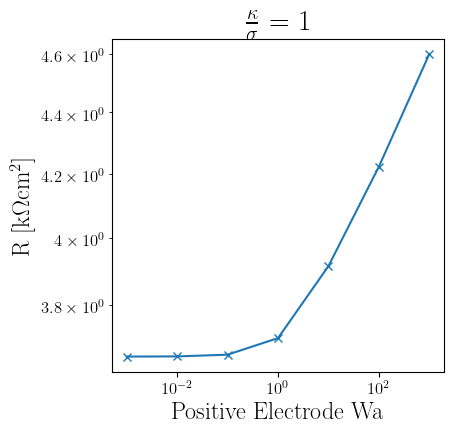

In [9]:
df_1 = df[np.isclose(df["Kr"], 1)]
slope_1 = []
x = df_1['Positive Wa'].to_numpy()
y = df_1['resistance [ohm.cm2]'].to_numpy()
for i in range(len(wagner_nums) - 1):
    slope_1.append((y[i+1] - y[i])/(x[i+1] - x[i]))
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(df_1['Positive Wa'], df_1['resistance [ohm.cm2]']/1000, 'x-')
ax.set_box_aspect(1)
ax.semilogx()
ax.semilogy()
ax.minorticks_on();
ax.set_ylabel(r'R [k$\Omega\mathrm{cm}^2$]', fontdict={'fontsize': 'x-large'})
ax.set_xlabel(r'$\mathrm{Positive\ Electrode\ Wa}$', fontdict={'fontsize': 'x-large'})
ax.set_title(r'$\frac{\kappa}{\sigma}$ = 1', fontdict={'fontsize': 'xx-large'})
plt.tight_layout()
plt.savefig(f'{workdir}/resistance-kr1.png', bbox_inches="tight", dpi=1200)

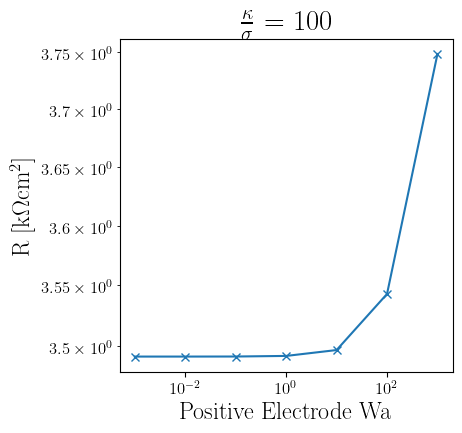

In [10]:
df_100 = df[np.isclose(df["Kr"], 100)]
slope_100 = []
x = df_100['Positive Wa'].to_numpy()
y = df_100['resistance [ohm.cm2]'].to_numpy()
for i in range(len(wagner_nums) - 1):
    slope_100.append((y[i+1] - y[i])/(x[i+1] - x[i]))
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(df_100['Positive Wa'], df_100['resistance [ohm.cm2]']/1000, 'x-')
ax.set_box_aspect(1)
ax.semilogx();
ax.semilogy();
ax.minorticks_on();
ax.set_ylabel(r'R [k$\Omega\mathrm{cm}^2$]', fontdict={'fontsize': 'x-large'})
ax.set_xlabel(r'$\mathrm{Positive\ Electrode\ Wa}$', fontdict={'fontsize': 'x-large'})
ax.set_title(r'$\frac{\kappa}{\sigma}$ = 100', fontdict={'fontsize': 'xx-large'})
plt.tight_layout()
plt.savefig(f'{workdir}/resistance-kr100.png', bbox_inches="tight", dpi=1200)